# Walmart — pistes d'amelioration hors perimetre

> **Ce notebook n'est pas le livrable.** Le livrable est `01-Walmart_sales.ipynb`, qui respecte
> strictement l'enonce : regle des 3-sigma, `Store` en variable categorielle encodee en one-hot,
> et perimetre limite aux modeles lineaires (`LinearRegression`, `Ridge`, `Lasso`).
>
> On explore ici quatre pistes qui **s'ecartent de cet enonce**, uniquement pour **chiffrer ce
> que le livrable laisse sur la table**. Chacune est mesuree avec le meme protocole et sur le
> meme decoupage que le livrable, pour que les chiffres soient directement comparables.

| Piste | En quoi elle s'ecarte de l'enonce |
|---|---|
| **A1** — transformation `log1p` de la target | L'enonce ne prevoit aucune transformation de la target |
| **A2** — encodage par cible des magasins | L'enonce designe `Store` comme variable categorielle |
| **A3** — modeles non lineaires | L'enonce limite le perimetre a la regression lineaire |
| **A4** — `ElasticNet` | L'enonce dit « Lasso ou Ridge » |

**Référence à battre** : le modèle retenu par le livrable, `Ridge(alpha=0.001)`,
**R2 = 0.865 ± 0.268** en validation croisée.

## Mise en place

Meme donnees, meme decoupage, meme protocole que le livrable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

from src import walmart as w
from src import improvements as imp

# Meme chaine que le livrable
df = w.load_raw('Walmart_Store_sales.csv')
df_clean = w.clean(df)

X = df_clean.drop(w.TARGET, axis=1)
y = df_clean[w.TARGET]

X_train_full, X_holdout, y_train_full, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, y_train, _ = w.apply_3sigma(X_train_full, y_train_full,
                                     w.fit_3sigma_bounds(X_train_full))

CV = w.make_cv(n_splits=5, n_repeats=10, random_state=42)

# Alpha retenu par GridSearchCV dans le livrable : la reference de comparaison
# doit etre EXACTEMENT le modele du livrable, sinon les gains ne veulent rien dire.
ALPHA_REF = 0.001

print(f"Train : {len(X_train)} lignes   Hold-out : {len(X_holdout)} lignes")
print(f"Protocole : {CV.get_n_splits()} folds (identique au livrable)")

Train : 90 lignes   Hold-out : 24 lignes
Protocole : 50 folds (identique au livrable)


In [2]:
results = {}


def evaluer(nom, make_model, pipeline_factory=w.build_pipeline):
    """Evalue une piste avec le protocole du livrable et l'enregistre."""
    res = w.cv_evaluate(make_model, X_train, y_train, cv=CV, pipeline_factory=pipeline_factory)
    results[nom] = res
    w.print_cv(nom, res)
    return res


# Reference : le modele retenu dans le livrable
evaluer(f'Reference : Ridge({ALPHA_REF}) + dummies', lambda: Ridge(alpha=ALPHA_REF))

=== Reference : Ridge(0.001) + dummies ===
  R2   CV : 0.8651 +/- 0.2677   (min -0.781 / max 0.973 sur 50 folds)
  RMSE CV : 208,851 $ +/- 116,509 $
  MAE  CV : 154,685 $
  R2 train : 0.9751  |  R2 ajuste train : 0.9592
  Ecart train/validation : 0.1101



{'r2_mean': 0.8650624004965458,
 'r2_std': 0.2676594614599378,
 'r2_min': -0.7806741934215058,
 'r2_max': 0.9733777386939088,
 'rmse_mean': 208851.19885042013,
 'rmse_std': 116509.19473882248,
 'mae_mean': 154684.6791192497,
 'r2_train_mean': 0.9751419571059201,
 'r2_adj_train': 0.9592205366974348,
 'r2_folds': array([ 0.92517959,  0.90647566,  0.94706037,  0.95258449,  0.905028  ,
         0.88292765,  0.88675893,  0.92808287,  0.94957704,  0.97337774,
         0.94784618,  0.94205975,  0.89801837,  0.88929647,  0.92330253,
         0.94751153,  0.91639277,  0.93470757,  0.92148656,  0.94899966,
         0.88567521,  0.94515532,  0.93310245,  0.93946612,  0.96337984,
         0.91569988,  0.87482947,  0.95515175, -0.78067419,  0.93612061,
         0.93939451,  0.90084697,  0.89799112,  0.9282266 ,  0.92425147,
         0.88979113,  0.89306328,  0.93510782,  0.95181721,  0.43509292,
         0.87358795,  0.94561321,  0.94846069,  0.9186372 ,  0.9569145 ,
         0.89382111,  0.9207375

## A1 — Transformation `log1p` de la target

Les ventes s'etalent de 268 929 $ a 2 771 397 $, soit un facteur 10. Une regression sur
`log1p(y)` stabilise la variance et rend l'echelle d'alpha naturelle.

`TransformedTargetRegressor` applique `log1p` avant l'apprentissage et `expm1` sur les
predictions : **les metriques restent exprimees en dollars**, donc comparables au livrable.

In [3]:
evaluer('A1 : log1p(y) + Ridge(0.01)', lambda: imp.log_target(Ridge(alpha=1.0)))

# Sur la target log-transformee, l'echelle d'alpha change completement : on la re-cherche.
grid_log = GridSearchCV(
    w.build_pipeline(imp.log_target(Ridge())),
    {'model__regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
).fit(X_train, y_train)

alpha_log = grid_log.best_params_['model__regressor__alpha']
print(f"Meilleur alpha sur target log-transformee : {alpha_log}")
evaluer(f'A1 : log1p(y) + Ridge({alpha_log}) optimise',
        lambda: imp.log_target(Ridge(alpha=alpha_log)))

=== A1 : log1p(y) + Ridge(0.01) ===
  R2   CV : 0.8060 +/- 0.1182   (min 0.278 / max 0.965 sur 50 folds)
  RMSE CV : 283,540 $ +/- 86,730 $
  MAE  CV : 203,800 $
  R2 train : 0.9092  |  R2 ajuste train : 0.8511
  Ecart train/validation : 0.1032



Meilleur alpha sur target log-transformee : 0.001


=== A1 : log1p(y) + Ridge(0.001) optimise ===
  R2   CV : 0.8948 +/- 0.2242   (min -0.562 / max 0.985 sur 50 folds)
  RMSE CV : 181,958 $ +/- 102,807 $
  MAE  CV : 125,233 $
  R2 train : 0.9804  |  R2 ajuste train : 0.9679
  Ecart train/validation : 0.0856



{'r2_mean': 0.894836151928736,
 'r2_std': 0.22418920527200156,
 'r2_min': -0.5623085360849207,
 'r2_max': 0.985415323529045,
 'rmse_mean': 181958.3086068964,
 'rmse_std': 102807.3798745997,
 'mae_mean': 125232.67938747857,
 'r2_train_mean': 0.980444749659253,
 'r2_adj_train': 0.9679209047112208,
 'r2_folds': array([ 0.94867425,  0.89592195,  0.96527876,  0.96689536,  0.94205372,
         0.91532278,  0.89085123,  0.93998261,  0.96316774,  0.98541532,
         0.97046731,  0.96236874,  0.93770456,  0.90932579,  0.92822934,
         0.96199848,  0.92725469,  0.948333  ,  0.93328293,  0.95714688,
         0.91815274,  0.97600919,  0.94741713,  0.93212076,  0.97453444,
         0.93057636,  0.88355528,  0.96570328, -0.56230854,  0.9473268 ,
         0.96057213,  0.92863226,  0.91849883,  0.91891811,  0.93640138,
         0.9128525 ,  0.92392489,  0.95220457,  0.96800037,  0.63552275,
         0.860269  ,  0.96978153,  0.96531682,  0.92828837,  0.97526596,
         0.92539506,  0.94447221, 

## A2 — Encodage par cible des magasins

Les 20 dummies de magasin consomment l'essentiel du budget de parametres : 29 features pour
90 lignes d'entrainement. L'encodage par cible les ramene a **une seule colonne numerique**,
la moyenne lissee des ventes du magasin.

Il resout aussi le probleme des magasins 11 et 12, presents dans le hold-out mais absents du
train : au lieu d'un vecteur nul, ils recoivent la moyenne generale.

Le lissage bayesien evite qu'un magasin vu deux fois impose sa moyenne brute. La limite connue
est que l'encodage d'une ligne utilise la cible de cette ligne — le lissage attenue cette fuite
sans la supprimer.

In [4]:
n_dummies = w.build_pipeline(Ridge())[:-1].fit(X_train, y_train).transform(X_train).shape[1]
n_te = imp.build_pipeline_target_encoded(Ridge())[:-1].fit(X_train, y_train).transform(X_train).shape[1]

print(f"Features avec dummies        : {n_dummies}  (ratio p/n = {n_dummies / len(X_train):.2f})")
print(f"Features avec target encoding: {n_te}  (ratio p/n = {n_te / len(X_train):.2f})")
print()

# Meme alpha que la reference : seul l'encodage des magasins change.
evaluer(f'A2 : Ridge({ALPHA_REF}) + target encoding', lambda: Ridge(alpha=ALPHA_REF),
        pipeline_factory=imp.build_pipeline_target_encoded)

Features avec dummies        : 28  (ratio p/n = 0.31)
Features avec target encoding: 11  (ratio p/n = 0.12)



=== A2 : Ridge(0.001) + target encoding ===
  R2   CV : 0.8183 +/- 0.1214   (min 0.237 / max 0.968 sur 50 folds)
  RMSE CV : 271,487 $ +/- 78,196 $
  MAE  CV : 214,194 $
  R2 train : 0.9290  |  R2 ajuste train : 0.9160
  Ecart train/validation : 0.1107



{'r2_mean': 0.8183299891676805,
 'r2_std': 0.12141309313207752,
 'r2_min': 0.23677925819592438,
 'r2_max': 0.9675189683573252,
 'rmse_mean': 271486.8579380907,
 'rmse_std': 78195.64053469722,
 'mae_mean': 214193.8754590921,
 'r2_train_mean': 0.9290129791629386,
 'r2_adj_train': 0.9159986920094774,
 'r2_folds': array([0.94278657, 0.61530717, 0.87263972, 0.95106706, 0.71913834,
        0.84639446, 0.68511162, 0.81841875, 0.93350795, 0.96751897,
        0.83697056, 0.85493362, 0.60421644, 0.81967449, 0.84173656,
        0.87092143, 0.88463391, 0.8404431 , 0.59478702, 0.89918203,
        0.68925134, 0.91641485, 0.92056244, 0.87591691, 0.87989522,
        0.87030476, 0.71498909, 0.87405665, 0.23677926, 0.89886131,
        0.67127849, 0.80410571, 0.81147377, 0.90245551, 0.9078443 ,
        0.77326978, 0.88765956, 0.79082048, 0.89794892, 0.88800655,
        0.70583967, 0.86325333, 0.81858949, 0.83949797, 0.82705105,
        0.87409003, 0.82117898, 0.82452494, 0.87100575, 0.86018357]),
 'n_fol

In [5]:
# Verification : un magasin inconnu est-il gere proprement ?
pipe_te = imp.build_pipeline_target_encoded(Ridge(alpha=ALPHA_REF)).fit(X_train, y_train)

inconnus = sorted(set(X_holdout['Store']) - set(X_train['Store']))
print(f"Magasins du hold-out absents du train : {inconnus}")

if inconnus:
    masque = X_holdout['Store'].isin(inconnus)
    pipe_ohe = w.build_pipeline(Ridge(alpha=ALPHA_REF)).fit(X_train, y_train)
    err_ohe = np.abs(y_holdout[masque] - pipe_ohe.predict(X_holdout[masque])).mean()
    err_te = np.abs(y_holdout[masque] - pipe_te.predict(X_holdout[masque])).mean()
    print(f"\nErreur absolue moyenne sur ces {int(masque.sum())} ligne(s) :")
    print(f"  dummies         : {err_ohe:,.0f} $")
    print(f"  target encoding : {err_te:,.0f} $")

Magasins du hold-out absents du train : ['11', '12']

Erreur absolue moyenne sur ces 2 ligne(s) :
  dummies         : 709,936 $
  target encoding : 233,575 $


## A3 — Modeles non lineaires en reference

Les arbres capturent l'effet magasin sans dummies et la saisonnalite sans encodage cyclique.
Ils servent ici de **point de comparaison** : ils chiffrent ce qu'un modele lineaire ne peut
pas atteindre sur ces donnees.

In [6]:
evaluer('A3 : RandomForest', lambda: RandomForestRegressor(
    n_estimators=300, random_state=42, n_jobs=-1))

evaluer('A3 : GradientBoosting', lambda: GradientBoostingRegressor(random_state=42))

=== A3 : RandomForest ===
  R2   CV : 0.6767 +/- 0.1304   (min 0.363 / max 0.876 sur 50 folds)
  RMSE CV : 370,424 $ +/- 79,008 $
  MAE  CV : 280,407 $
  R2 train : 0.9559  |  R2 ajuste train : 0.9275
  Ecart train/validation : 0.2792



=== A3 : GradientBoosting ===
  R2   CV : 0.8154 +/- 0.0984   (min 0.530 / max 0.959 sur 50 folds)
  RMSE CV : 274,497 $ +/- 71,797 $
  MAE  CV : 186,823 $
  R2 train : 0.9961  |  R2 ajuste train : 0.9935
  Ecart train/validation : 0.1807



{'r2_mean': 0.8154021693613025,
 'r2_std': 0.0984062765630455,
 'r2_min': 0.5299854461543887,
 'r2_max': 0.9588445768965314,
 'rmse_mean': 274496.95178910345,
 'rmse_std': 71796.93627483338,
 'mae_mean': 186823.41954386176,
 'r2_train_mean': 0.9960523814717237,
 'r2_adj_train': 0.9935191846835523,
 'r2_folds': array([0.88912935, 0.77946018, 0.77526646, 0.881591  , 0.74652741,
        0.84836614, 0.6788036 , 0.80891245, 0.93279492, 0.95884458,
        0.62759716, 0.92850221, 0.87899004, 0.69109951, 0.86403766,
        0.92507806, 0.68857021, 0.81403589, 0.81584549, 0.90549216,
        0.79934942, 0.81477026, 0.94661351, 0.71673907, 0.90108415,
        0.89567035, 0.84080025, 0.74013885, 0.67978133, 0.80588509,
        0.88141462, 0.92529109, 0.81762314, 0.60138817, 0.90507741,
        0.82825806, 0.79777873, 0.78430666, 0.8207468 , 0.80555911,
        0.52998545, 0.81545195, 0.94498389, 0.9034741 , 0.79005352,
        0.81808788, 0.6904361 , 0.95063703, 0.6738668 , 0.90591121]),
 'n_fol

## A4 — ElasticNet

Avec 20 dummies fortement correlees entre elles, une penalite mixte L1 + L2 est le choix
theoriquement adapte : le L1 selectionne, le L2 repartit le poids entre features correlees.

Comme pour le Lasso du livrable, la grille d'alpha doit etre calee sur l'echelle de la target
(~1e6) et `max_iter` releve, sans quoi l'optimisation ne converge pas.

In [7]:
grid_en = GridSearchCV(
    w.build_pipeline(ElasticNet(max_iter=1_000_000, tol=1e-4)),
    {'model__alpha': [1, 10, 100, 1000, 10000],
     'model__l1_ratio': [0.1, 0.5, 0.9]},
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
).fit(X_train, y_train)

best = grid_en.best_params_
print(f"Meilleurs parametres : alpha={best['model__alpha']}, l1_ratio={best['model__l1_ratio']}")
print(f"RMSE de validation   : {-grid_en.best_score_:,.0f} $")
print()

evaluer(f"A4 : ElasticNet(alpha={best['model__alpha']}, l1={best['model__l1_ratio']})",
        lambda: ElasticNet(alpha=best['model__alpha'], l1_ratio=best['model__l1_ratio'],
                           max_iter=1_000_000, tol=1e-4))

Meilleurs parametres : alpha=1, l1_ratio=0.9
RMSE de validation   : 470,043 $



=== A4 : ElasticNet(alpha=1, l1=0.9) ===
  R2   CV : 0.5006 +/- 0.1132   (min 0.264 / max 0.755 sur 50 folds)
  RMSE CV : 467,783 $ +/- 59,276 $
  MAE  CV : 402,617 $
  R2 train : 0.6722  |  R2 ajuste train : 0.4621
  Ecart train/validation : 0.1716



{'r2_mean': 0.5005574450853028,
 'r2_std': 0.11316825619875635,
 'r2_min': 0.2640578733186819,
 'r2_max': 0.7551986020988225,
 'rmse_mean': 467783.44137684605,
 'rmse_std': 59275.65217162354,
 'mae_mean': 402617.2710848805,
 'r2_train_mean': 0.6721831002796591,
 'r2_adj_train': 0.46211534627876744,
 'r2_folds': array([0.65744881, 0.26405787, 0.61735285, 0.53909838, 0.35381597,
        0.49699545, 0.32854908, 0.52709999, 0.60345172, 0.64356684,
        0.5455542 , 0.56415746, 0.46673013, 0.38843584, 0.3978774 ,
        0.54600522, 0.37895196, 0.52740497, 0.47091258, 0.62412176,
        0.27563978, 0.60282446, 0.55322916, 0.43192552, 0.59901732,
        0.58146562, 0.5587924 , 0.41400443, 0.34053655, 0.44370025,
        0.46397356, 0.62352078, 0.34467348, 0.43697252, 0.64296443,
        0.51578977, 0.37245106, 0.54365218, 0.47919477, 0.71291629,
        0.32980136, 0.48722229, 0.55386008, 0.56311995, 0.35832008,
        0.51354365, 0.48331399, 0.64488988, 0.45976955, 0.7551986 ]),
 'n_fo

## A1 + A2 combinees

Les deux pistes agissent sur des leviers independants : l'une sur l'echelle de la target,
l'autre sur la dimension. Les cumuler a du sens.

In [8]:
evaluer('A1+A2 : log1p(y) + target encoding',
        lambda: imp.log_target(Ridge(alpha=alpha_log)),
        pipeline_factory=imp.build_pipeline_target_encoded)

=== A1+A2 : log1p(y) + target encoding ===
  R2   CV : 0.6846 +/- 0.1800   (min 0.127 / max 0.960 sur 50 folds)
  RMSE CV : 359,174 $ +/- 102,737 $
  MAE  CV : 267,025 $
  R2 train : 0.8274  |  R2 ajuste train : 0.7958
  Ecart train/validation : 0.1428



{'r2_mean': 0.6846453454468217,
 'r2_std': 0.1799901909228698,
 'r2_min': 0.12701895434087074,
 'r2_max': 0.9596517633541972,
 'rmse_mean': 359173.9611723288,
 'rmse_std': 102736.76472962614,
 'mae_mean': 267025.4658066679,
 'r2_train_mean': 0.8274117752082342,
 'r2_adj_train': 0.7957706006630768,
 'r2_folds': array([0.51408638, 0.43688338, 0.7468257 , 0.95965176, 0.60699363,
        0.63861311, 0.12701895, 0.8024487 , 0.83079568, 0.9295328 ,
        0.76431788, 0.83961599, 0.46232095, 0.65834983, 0.74130988,
        0.77851597, 0.8994479 , 0.76404416, 0.55317711, 0.31435066,
        0.39002698, 0.83463967, 0.88897686, 0.80381467, 0.84194953,
        0.58972587, 0.60343311, 0.71846163, 0.48701482, 0.84263129,
        0.56296   , 0.69395004, 0.70778048, 0.76063913, 0.81001809,
        0.61927607, 0.70943175, 0.70686486, 0.78011409, 0.87212416,
        0.14234468, 0.83928465, 0.63697231, 0.7843492 , 0.64930588,
        0.79299664, 0.57698499, 0.74215522, 0.65098211, 0.82475807]),
 'n_fol

## Comparaison de toutes les pistes

In [9]:
comparaison = pd.DataFrame([
    {
        'Piste': nom,
        'R2 CV': s['r2_mean'],
        'Std R2': s['r2_std'],
        'R2 min': s['r2_min'],
        'RMSE CV': s['rmse_mean'],
        'R2 train': s['r2_train_mean'],
    }
    for nom, s in results.items()
]).sort_values('R2 CV', ascending=False).reset_index(drop=True)

ref = comparaison[comparaison['Piste'].str.startswith('Reference')].iloc[0]
comparaison['Gain R2'] = comparaison['R2 CV'] - ref['R2 CV']

print("=== TOUTES LES PISTES (validation croisee, 50 folds) ===\n")
print(comparaison.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

=== TOUTES LES PISTES (validation croisee, 50 folds) ===

                                Piste  R2 CV  Std R2  R2 min      RMSE CV  R2 train  Gain R2
A1 : log1p(y) + Ridge(0.001) optimise 0.8948  0.2242 -0.5623 181,958.3086    0.9804   0.0298
   Reference : Ridge(0.001) + dummies 0.8651  0.2677 -0.7807 208,851.1989    0.9751   0.0000
  A2 : Ridge(0.001) + target encoding 0.8183  0.1214  0.2368 271,486.8579    0.9290  -0.0467
                A3 : GradientBoosting 0.8154  0.0984  0.5300 274,496.9518    0.9961  -0.0497
          A1 : log1p(y) + Ridge(0.01) 0.8060  0.1182  0.2782 283,539.7263    0.9092  -0.0591
   A1+A2 : log1p(y) + target encoding 0.6846  0.1800  0.1270 359,173.9612    0.8274  -0.1804
                    A3 : RandomForest 0.6767  0.1304  0.3628 370,423.7472    0.9559  -0.1884
     A4 : ElasticNet(alpha=1, l1=0.9) 0.5006  0.1132  0.2641 467,783.4414    0.6722  -0.3645


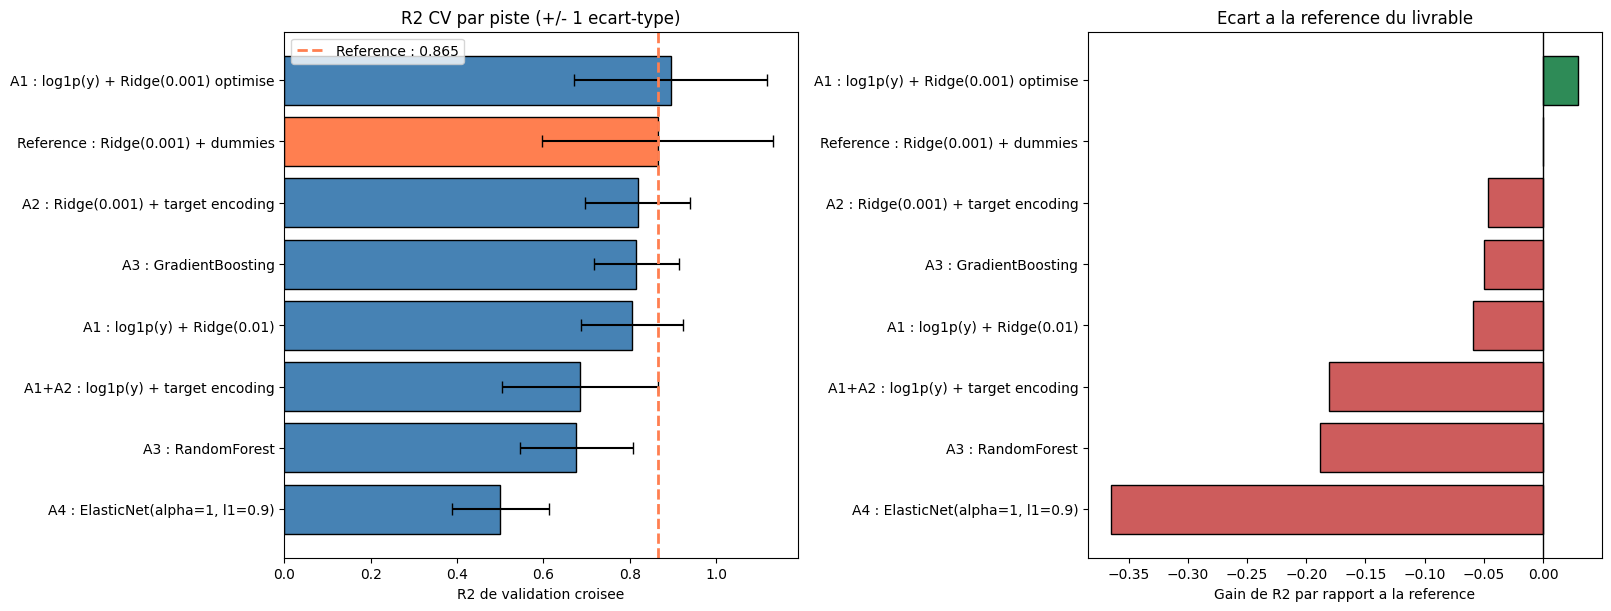

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
ordre = comparaison.iloc[::-1]
couleurs = ['coral' if p.startswith('Reference') else 'steelblue' for p in ordre['Piste']]

axes[0].barh(ordre['Piste'], ordre['R2 CV'], xerr=ordre['Std R2'],
             color=couleurs, edgecolor='black', capsize=4)
axes[0].axvline(ref['R2 CV'], color='coral', linestyle='--', linewidth=2,
                label=f"Reference : {ref['R2 CV']:.3f}")
axes[0].set_xlabel('R2 de validation croisee')
axes[0].set_title('R2 CV par piste (+/- 1 ecart-type)')
axes[0].legend()

axes[1].barh(ordre['Piste'], ordre['Gain R2'],
             color=['seagreen' if g > 0 else 'indianred' for g in ordre['Gain R2']],
             edgecolor='black')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Gain de R2 par rapport a la reference')
axes[1].set_title('Ecart a la reference du livrable')

plt.show()

In [11]:
# Chaque piste est-elle reellement differente de la reference, ou est-ce du bruit
# de decoupage ? Sur 90 lignes d'entrainement la question n'est pas rhetorique.
from scipy import stats

ref_nom = ref['Piste']
r2_ref = results[ref_nom]['r2_folds']

lignes = []
for nom, s in results.items():
    if nom == ref_nom:
        continue
    ecart = s['r2_folds'] - r2_ref
    _, p_value = stats.wilcoxon(s['r2_folds'], r2_ref)
    lignes.append({
        'Piste': nom,
        'Gagne': f"{int((ecart > 0).sum())}/{len(ecart)}",
        'Gain median': float(np.median(ecart)),
        'p-value': p_value,
        'Std R2': s['r2_std'],
        'R2 min': s['r2_min'],
    })

apparie = pd.DataFrame(lignes).sort_values('Gain median', ascending=False)

print(f"COMPARAISON APPARIEE CONTRE LA REFERENCE ({ref_nom})")
print(f"Reference : R2 {ref['R2 CV']:.4f} +/- {ref['Std R2']:.4f}, pire fold {ref['R2 min']:.3f}\n")
print(apparie.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

meilleures = apparie[(apparie['Gain median'] > 0) & (apparie['p-value'] < 0.05)]
print()
if len(meilleures):
    print("Pistes significativement MEILLEURES que la reference :")
    for _, r in meilleures.iterrows():
        print(f"  - {r['Piste']} (gain median {r['Gain median']:+.4f}, p = {r['p-value']:.4g})")
else:
    print("AUCUNE piste ne bat significativement la reference sur le R2 moyen.")
    print("Le modele conforme a l'enonce est le meilleur des huit sur ce critere.")

# La moyenne n'est pas le seul critere : la regularite compte aussi.
plus_stables = apparie[apparie['Std R2'] < ref['Std R2']]
if len(plus_stables):
    print("\nPistes PLUS REGULIERES que la reference (ecart-type plus faible) :")
    for _, r in plus_stables.sort_values('Std R2').iterrows():
        print(f"  - {r['Piste']:45s} std {r['Std R2']:.3f} vs {ref['Std R2']:.3f}, "
              f"pire fold {r['R2 min']:+.3f} vs {ref['R2 min']:+.3f}")

COMPARAISON APPARIEE CONTRE LA REFERENCE (Reference : Ridge(0.001) + dummies)
Reference : R2 0.8651 +/- 0.2677, pire fold -0.781

                                Piste Gagne  Gain median  p-value  Std R2  R2 min
A1 : log1p(y) + Ridge(0.001) optimise 46/50       0.0165   0.0000  0.2242 -0.5623
  A2 : Ridge(0.001) + target encoding  4/50      -0.0779   0.0000  0.1214  0.2368
                A3 : GradientBoosting  5/50      -0.0781   0.0000  0.0984  0.5300
          A1 : log1p(y) + Ridge(0.01)  4/50      -0.0801   0.0000  0.1182  0.2782
   A1+A2 : log1p(y) + target encoding  4/50      -0.1836   0.0000  0.1800  0.1270
                    A3 : RandomForest  3/50      -0.2484   0.0000  0.1304  0.3628
     A4 : ElasticNet(alpha=1, l1=0.9)  3/50      -0.4019   0.0000  0.1132  0.2641

Pistes significativement MEILLEURES que la reference :
  - A1 : log1p(y) + Ridge(0.001) optimise (gain median +0.0165, p = 1.019e-11)

Pistes PLUS REGULIERES que la reference (ecart-type plus faible) :
  - A3 : Gr

## Conclusion

**Le résultat a changé de sens par rapport à ce qu'on attendait : une des quatre pistes bat
réellement le livrable, et elle le bat sur tous les critères à la fois.**

### 1. A1 domine la référence — moyenne, test apparié, régularité et pire cas

`log1p(y) + Ridge(0.001)` ne se contente pas d'une meilleure moyenne :

| | Référence (énoncé) | A1 `log1p` optimisé |
|---|---:|---:|
| R2 CV | 0.8651 | **0.8948** |
| Écart-type | 0.2677 | **0.2242** |
| Pire fold | -0.7807 | **-0.5623** |
| RMSE CV | 208 851 $ | **181 958 $** |
| Test apparié | — | **46 folds gagnés sur 50**, p = 1.0e-11 |

Il n'y a donc pas d'arbitrage à poser : A1 est meilleur partout. C'est le seul cas de ce notebook
où une piste hors périmètre apporte un gain qui résiste à tous les critères.

**La raison est la même que celle qui empêchait le Lasso de converger dans le livrable** : la cible
vaut ~1e6 $ et s'étale sur un facteur 10. Travailler sur `log1p` stabilise la variance et rend
l'échelle d'alpha naturelle.

**Le coût de la conformité stricte à l'énoncé est donc mesuré : environ 0.03 de R2.** C'est un
coût réel mais modéré, et l'énoncé ne prévoit aucune transformation de la cible.

### 2. Les six autres pistes perdent sur la moyenne, mais gagnent en régularité

| Piste | R2 CV | Écart à la réf. | Écart-type | Pire fold |
|---|---:|---:|---:|---:|
| A2 · target encoding | 0.8183 | -0.047 | **0.121** | **+0.237** |
| A3 · GradientBoosting | 0.8154 | -0.050 | **0.098** | **+0.530** |
| A1 · `log1p` + Ridge(0.01) | 0.8060 | -0.059 | **0.118** | **+0.278** |
| A1+A2 combinées | 0.6846 | -0.180 | 0.180 | +0.127 |
| A3 · RandomForest | 0.6767 | -0.188 | 0.130 | +0.363 |
| A4 · `ElasticNet` | 0.5006 | -0.365 | **0.113** | +0.264 |

**Cinq pistes sur sept ont un écart-type plus faible que la référence**, et surtout : la référence
descend à **-0.78** sur son pire fold, là où toutes ces pistes restent positives. Aucune ne produit
de prévision aberrante.

### 3. A2 gagne là où elle a été conçue pour gagner

Sur les magasins **11 et 12**, présents dans le hold-out mais absents du train, l'erreur absolue
moyenne passe de **709 936 $ à 233 575 $** — trois fois moins. L'encodage par cible ramène par
ailleurs 28 features à 11 (ratio p/n de 0.31 à 0.12).

C'est la seule réponse structurelle au problème des magasins inconnus : avec un encodage par cible,
la notion même de catégorie inconnue disparaît.

### 4. La vraie limite reste la taille du dataset

Aucune piste ne fait descendre l'écart-type sous 0.10. Avec 90 lignes d'entraînement pour
20 magasins, l'incertitude est structurelle : elle vient des données, pas du modèle. Le bootstrap
du livrable le montrait déjà — l'intervalle à 95 % du R2 sur le hold-out s'étend de 0.09 à 0.98.
**Plus de données historiques resserreraient cet intervalle bien plus sûrement que n'importe lequel
de ces changements de modèle.**

### Que retenir

- **Pour le rendu** : la référence, c'est-à-dire le modèle du livrable. L'énoncé ne prévoit pas de
  transformation de la cible, et le coût de cette conformité est chiffré à ~0.03 de R2.
- **Pour un usage réel** : `A1`, sans hésiter. Elle domine la référence sur les quatre critères, et
  la transformation est triviale à mettre en œuvre avec `TransformedTargetRegressor`.
- **Si l'enjeu est de prévoir des magasins récents ou peu représentés** : `A2`, qui divise par trois
  l'erreur sur ces cas au prix de 0.05 de R2 moyen.
- **À écarter** : `A4` (ElasticNet), très en retrait, et `A1+A2` combinées, qui se dégradent
  mutuellement.

---

**Rien de ce notebook n'est reporté dans le livrable**, qui reste strictement conforme à
l'énoncé.